**Disciplina: Aprendizagem de Máquina**

Período: 2025.2 e 2026.1

Professor: César Lincoln Cavalcante Mattos

Aluno: José Wilson Aguiar Júnior

**Lista 2 - Regressão logística, métodos estatísticos, KNN e
Árvores de decisão**


**Instruções**


*   Algoritmos e modelos de implementações já existentes (e.g. scikit-learn) podem ser usados;

*   Use de prints, gráficos e tabelas para apresentar o ajuste dos modelos e os
resultados obtidos;

*   Para a avaliação do trabalho, recomenda-se o envio de arquivo Jupyter notebook com os códigos executados e os resultados visíveis nas células.



In [2]:
#Fazendo o upload do arquivo californiabin.csv

from google.colab import files
uploaded = files.upload()

Saving californiabin.csv to californiabin.csv


In [ ]:
# Importando o arquivo californiabin.csv

import pandas as pd

# Ler o arquivo
df = pd.read_csv('californiabin.csv')

# Exibir todas as colunas
print("Colunas do californiabin.csv:")
print(df.columns.tolist())

# Número de linhas e colunas
linhas, colunas = df.shape
print(f"\nNúmero de linhas: {linhas}")
print(f"Número de colunas: {colunas}")

Colunas do californiabin.csv:
['4.168499999999999872e+00', '2.000000000000000000e+01', '6.700636942675159524e+00', '1.178343949044585948e+00', '7.450000000000000000e+02', '2.372611464968152895e+00', '3.879999999999999716e+01', '-1.211500000000000057e+02', '1.000000000000000000e+00']

Número de linhas: 1999
Número de colunas: 9


**Questão 1**


Considere o conjunto de dados disponível em californiabin.csv, organizado
em 9 colunas, sendo as 8 primeiras colunas os atributos e a última coluna a
saída. Os 8 atributos são usados na predição de preços de casas em distritos
da Califórnia na década de 1990. A saída é binária: 0, para abaixo da mediana
dos preços; 1, para acima da mediana dos preços. Maiores detalhes sobre os dados podem ser conferidos em https://scikit-learn.org/stable/datasets/real_world.html#california-housing-dataset.

a) Considerando uma validação cruzada aninhada (nested K-fold) com
10 folds externos (estimação da generalização) e 5 folds internos (ajuste
de hiperparâmetros), avalie modelos de classificação binária nos dados
em questão. Para tanto, use as abordagens abaixo:

– Regressão logística;

– Análise do discriminante Gaussiano;

– Naive Bayes Gaussiano;

– KNN;

– Árvore de decisão.

**Regressão logística**

Resultados da Regressão Logística:

Accuracy:
  Scores: ['0.8650', '0.8850', '0.8450', '0.8500', '0.8300', '0.8550', '0.8000', '0.8500', '0.8150', '0.8291']
  Média: 0.8424
  Desvio padrão: 0.0234

Precision:
  Scores: ['0.8544', '0.8889', '0.8632', '0.8365', '0.7895', '0.8515', '0.8000', '0.8571', '0.8387', '0.8218']
  Média: 0.8402
  Desvio padrão: 0.0284

Recall:
  Scores: ['0.8800', '0.8800', '0.8200', '0.8700', '0.9000', '0.8600', '0.8000', '0.8400', '0.7800', '0.8384']
  Média: 0.8468
  Desvio padrão: 0.0364

F1:
  Scores: ['0.8670', '0.8844', '0.8410', '0.8529', '0.8411', '0.8557', '0.8000', '0.8485', '0.8083', '0.8300']
  Média: 0.8429
  Desvio padrão: 0.0241

Roc_auc:
  Scores: ['0.9263', '0.9476', '0.9224', '0.9264', '0.9030', '0.9253', '0.8808', '0.9151', '0.9080', '0.9172']
  Média: 0.9172
  Desvio padrão: 0.0167



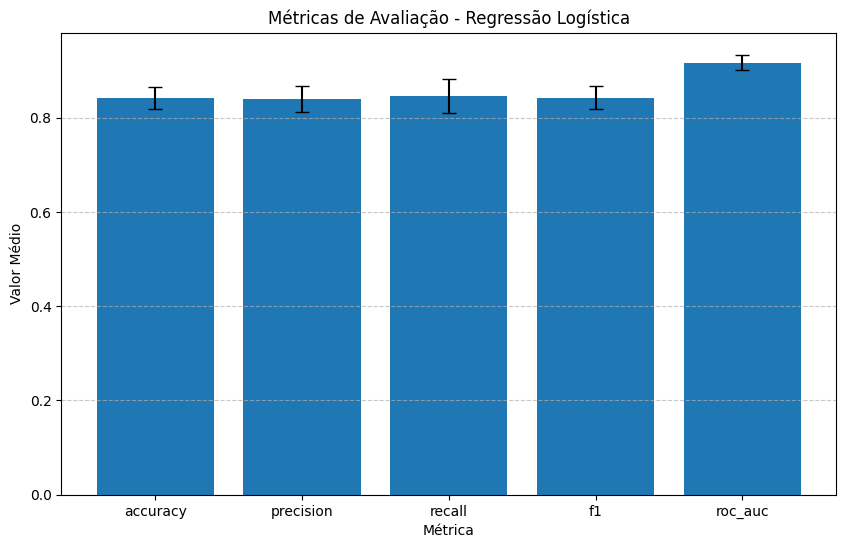

In [16]:
# Importações de bibliotecas necessárias para carregar dados, processamento e visualização
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Importações do scikit-learn para modelagem, validação e pipelines
from sklearn.model_selection import cross_validate, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression  # Modelo de regressão logística
from sklearn.pipeline import Pipeline                # Para encadear transformações e modelo
from sklearn.preprocessing import StandardScaler     # Para padronizar os dados

# Carregar o conjunto de dados fornecido
# O arquivo 'californiabin.csv' contém 8 features e 1 target binário
df = pd.read_csv('californiabin.csv')

# Separar as variáveis independentes (X) e a variável dependente (y)
# As 8 primeiras colunas são os atributos (features)
# Contamos as colunas de 0 a 8 totalizando 9 colunas
X = df.iloc[:, :8] # o ':8' seleciona todas as colunas de 0 a 7
# A 9ª coluna é a saída binária (0 ou 1)
y = df.iloc[:, 8] # o '8' seleciona somente a ultima coluna que é a 9° coluna

# Pipeline: classe do scit-learn que permite aplicar transformações (padronização) e modelo em sequência
# para evitar vazamento de dados entre treino e teste
pipe = Pipeline([
    ('scaler', StandardScaler()),      # idenficamos a primeira etapa do pipeline (scaler) e padronizamos os dados (média zero e desvio padrão 1) com o objeto StandardScaler
    ('logreg', LogisticRegression(max_iter=1000))  # idenfificamos a segunda etapa do pipeline (logreg), usamos o modelo de regressão logística 'LogisticRegression' e definimos o número máximo de iterações em mil 'max_iter=1000'
])

# Definir um grid de hiperparâmetros para ajuste automático
# Ajustar o parâmetro de regularização inversa 'C' para evitar que o modelo memorize os dados de treino e não generalize para novos dados
param_grid = { #param_grid é o dicionário que usamos para definir os hiperparâmetros usado pela biblioteca GridSearchCV para testar todas as combinações possíveis dentro de cada fold inerno da validação cruzada
    'logreg__C': [0.1, 1, 10],        # 'logreg__C' é o parâmetro de regularização da Regressão Logística dentro do pipeline e [0.1, 1, 10] são os valores que serão testados para o parâmetro C
    'logreg__solver': ['liblinear']    # 'logreg__solver' é o parâmetro que define qual algoritmo será usado para treinar o modelo e 'liblinear' é o tipo de solver (parâmetro) adequado para conjuntos de dados pequenos.
}

# Configurar validação cruzada interna para ajuste de hiperparâmetros
# 5 folds internos
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # 'inner_cv' é a validação usada para escolher os melhores hiperparâmetros, 'StratifiedKFold' usado pelo scikit-learn divide os dados em folds mantendo a proporção de classes, 'n_splits=5' cria 5 grupos para validação cruzada interna, 'shuffle=True' embaralha os dados antes de dividir, 'random_state=42' garante reprodutibilidade.


# GridSearchCV busca os melhores hiperparâmetros dentro de cada fold interno
# Isso evita overfitting nos hiperparâmetros
grid_search = GridSearchCV(pipe, param_grid, cv=inner_cv, scoring='accuracy', n_jobs=-1) #'grid_search' é o objeto usado para validação cruzada externa (10 folds) para o GridSearchCV encontrar os melhores hiperparêmetros, pipe → Pipeline com transformações e modelo, 'param_grid' testa combinações de hiperparâmetros, 'cv=inner_cv' define validação cruzada interna (5 folds), scoring='accuracy' métrica usada para comparar os modelos, n_jobs=-1 usa todos os núcleos do processador para acelerar os cálculos.

# Configurar validação cruzada externa para estimar a performance real do modelo
# 10 folds externos (como pedido no enunciado)
outer_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42) # 'outer_cv' variável que armazena a estratégia de validação cruzada externa, 'StratifiedKFold' divisão dos dados mantendo a proporção de classes, 'n_splits=10' 10 grupos para validação cruzada externa, 'shuffle=True' embaralha os dados antes de dividir e 'random_state=42' garante reprodutibilidade.

# Lista de métricas a serem avaliadas no modelo
# Accuracy: fração de acertos
# Precision: qualidade das previsões positivas
# Recall: cobertura dos positivos reais
# F1: média harmônica entre precision e recall
# Roc-Auc: Classificação Binária
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# Aplicar validação cruzada aninhada com múltiplas métricas
# Retorna um dicionário com os scores para cada métrica
nested_results = cross_validate(grid_search, X, y, cv=outer_cv, scoring=scoring, # 'nested_results' armazena os resultados da validação cruzada, 'cross_validate' função que executa validação cruzada com múltiplas métricas, 'grid_search' objeto que encapsula o modelo e busca de hiperparâmetros, 'X e y' são os dados de entrada, 'cv=outer_cv' definie os 10 folds externos, 'scoring=scoring' define as métricas a serem calculadas
                               return_train_score=False, n_jobs=-1) #'return_train_score=False' não retorna scores de treino, 'n_jobs=-1' usa todos os núcelos do processador para acelerar os cálculos

# Exibir os resultados para cada métrica
print("Resultados da Regressão Logística:\n")

# Iterar sobre cada métrica e imprimir os scores individuais e médios
for metric in scoring: #loope que percore cada métrica definida em scoring (accuracy, precision, recall e f1)
    scores = nested_results[f'test_{metric}']  # extrai/cria os scores de teste para a métrica, 'nasted_results' é um dicionário retornado pelo cross_validate
    print(f"{metric.capitalize()}:")           # imprime o nome da métrica com a primeira letra maiúscula
    print(f"  Scores: {[f'{s:.4f}' for s in scores]}")  # imprime os scores individuais para cada fold pegando cada score do array formatando em 4 casas deciamais
    print(f"  Média: {scores.mean():.4f}")              # imprime a média dos scores formatando em 4 casas decimais
    print(f"  Desvio padrão: {scores.std():.4f}\n")     # imprime o desvio padrão dos scores, formatando em 4 casas decimais e adicionando uma linha para espaçamento

# Visualização gráfica das métricas
# Calcula média e desvio padrão de cada métrica para plotagem
# variável que vai armazenar o dicionário resultante com as médias das métricas de avaliação
metrics_mean = {m: nested_results[f'test_{m}'].mean() for m in scoring} #'metrics_mean' variável que armazena o dicionário final, 'm' variável temporária que assume cada métrica, 'nested_results' dicionário com os scores de cada métrica, 'f'test_{m}'' chave dinâmica para acessar o array de scores, '.mean()' usada pela biblioteca Numpy/Pandas e calcula a média dos scores e 'for m in scoring' loop que percorre todas as métricas
metrics_std = {m: nested_results[f'test_{m}'].std() for m in scoring}  #'metrics_mean' variável que armazena o dicionário final, 'm' variável temporária que assume cada métrica, 'nested_results' dicionário com os scores de cada métrica, 'f'test_{m}'' chave dinâmica para acessar o array de scores, '.std()' usada pela biblioteca Numpy/Pandas e calcula a desvio padrão dos scores e 'for m in scoring' loop que percorre todas as métricas

# Gráfico de barras mostrando as métricas e suas variações
plt.figure(figsize=(10, 6)) #definimos o tameno da figura em 10 polegadas de largura e 6 polegadas de altura
plt.bar(metrics_mean.keys(), metrics_mean.values(), yerr=list(metrics_std.values()), capsize=5) #'plt.bar' cria um gráfico de barras, 'metrics_mean.keys()' chama o nome das métricas, 'metrics_mean.values()' chama os valores médios das métricas (altura das barras), 'yerr=list(metrics_std.values())' barras de desvios padrão, 'capsize=5' tamaho das barbas nas extremidades das barras de erro
plt.title('Métricas de Avaliação - Regressão Logística') #imprime o título do gráfico
plt.ylabel('Valor Médio') # imprime o rótulo do eixo y
plt.xlabel('Métrica') #imprime o rótulo do eixo x
plt.grid(axis='y', linestyle='--', alpha=0.7) #imprime as linhas de grade no eixo y, 'linestyle='--'' traços pontilhados, 'alpha-0,7' trabsparência das linhas
plt.show() #plota o gráfico

**Análise do discriminante Gaussiano**

Resultados da Análise do Discriminante Gaussiano:

Accuracy:
  Scores: ['0.8800', '0.8800', '0.8300', '0.8200', '0.8350', '0.8550', '0.7800', '0.8750', '0.8200', '0.8241']
  Média: 0.8399
  Desvio padrão: 0.0307

Precision:
  Scores: ['0.8654', '0.8654', '0.8173', '0.8137', '0.7965', '0.8515', '0.7642', '0.8571', '0.8333', '0.7909']
  Média: 0.8255
  Desvio padrão: 0.0331

Recall:
  Scores: ['0.9000', '0.9000', '0.8500', '0.8300', '0.9000', '0.8600', '0.8100', '0.9000', '0.8000', '0.8788']
  Média: 0.8629
  Desvio padrão: 0.0371

F1:
  Scores: ['0.8824', '0.8824', '0.8333', '0.8218', '0.8451', '0.8557', '0.7864', '0.8780', '0.8163', '0.8325']
  Média: 0.8434
  Desvio padrão: 0.0301

Roc_auc:
  Scores: ['0.9239', '0.9522', '0.9203', '0.9186', '0.8995', '0.9218', '0.8782', '0.9093', '0.9032', '0.9164']
  Média: 0.9143
  Desvio padrão: 0.0182



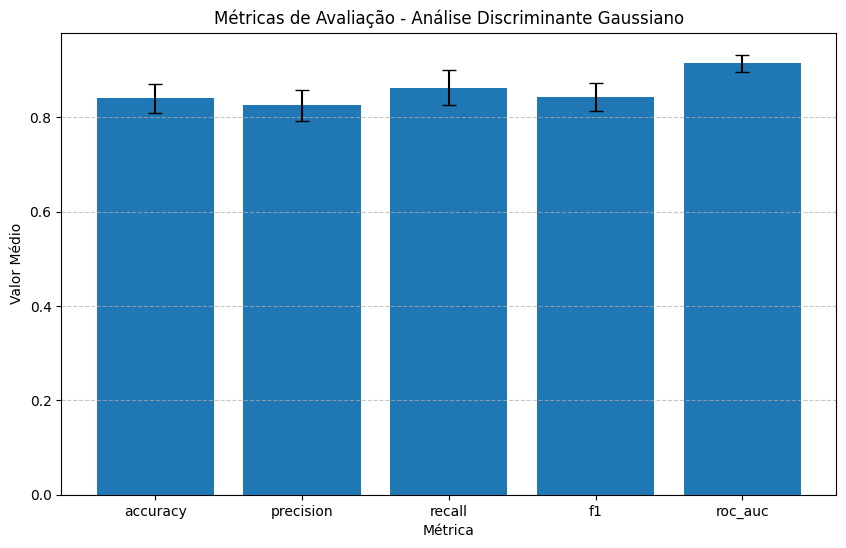

In [22]:
# Importações de bibliotecas necessárias para carregar dados, processamento e visualização
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Importações do scikit-learn para modelagem, validação e pipelines
from sklearn.model_selection import cross_validate, GridSearchCV, StratifiedKFold
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis # Modelo análise do discriminante gaussiano
from sklearn.pipeline import Pipeline                # Para encadear transformações e modelo
from sklearn.preprocessing import StandardScaler     # Para padronizar os dados

# Carregar o conjunto de dados fornecido
# O arquivo 'californiabin.csv' contém 8 features e 1 target binário
df = pd.read_csv('californiabin.csv')

# Separar as variáveis independentes (X) e a variável dependente (y)
# As 8 primeiras colunas são os atributos (features)
# Contamos as colunas de 0 a 8 totalizando 9 colunas
X = df.iloc[:, :8] # o ':8' seleciona todas as colunas de 0 a 7
# A 9ª coluna é a saída binária (0 ou 1)
y = df.iloc[:, 8] # o '8' seleciona somente a ultima coluna que é a 9° coluna

# Pipeline: classe do scit-learn que permite aplicar transformações (padronização) e modelo em sequência
# para evitar vazamento de dados entre treino e teste
pipe = Pipeline([
    ('scaler', StandardScaler()),      # idenficamos a primeira etapa do pipeline (scaler) e padronizamos os dados (média zero e desvio padrão 1) com o objeto StandardScaler
    ('lda', LinearDiscriminantAnalysis())  # segunda etapa do pipeline (lda), usamos o modelo de análise do discriminante gaussiano 'LinearDiscriminantAnalysis'
])

# análise do discriminante gaussiano (LDA) não tem muitos hiperparâmetros para ajustar, mas vamos definir um grid vazio
# para manter a mesma estrutura de GridSearchCV
param_grid = {}

# Configurar validação cruzada interna para ajuste de hiperparâmetros
# 5 folds internos
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # 'inner_cv' é a validação usada para escolher os melhores hiperparâmetros, 'StratifiedKFold' usado pelo scikit-learn divide os dados em folds mantendo a proporção de classes, 'n_splits=5' cria 5 grupos para validação cruzada interna, 'shuffle=True' embaralha os dados antes de dividir, 'random_state=42' garante reprodutibilidade.


# GridSearchCV busca os melhores hiperparâmetros dentro de cada fold interno
# Isso evita overfitting nos hiperparâmetros
grid_search = GridSearchCV(pipe, param_grid, cv=inner_cv, scoring='accuracy', n_jobs=-1) #'grid_search' é o objeto usado para validação cruzada externa (10 folds) para o GridSearchCV encontrar os melhores hiperparêmetros, pipe → Pipeline com transformações e modelo, 'param_grid' testa combinações de hiperparâmetros, 'cv=inner_cv' define validação cruzada interna (5 folds), scoring='accuracy' métrica usada para comparar os modelos, n_jobs=-1 usa todos os núcleos do processador para acelerar os cálculos.

# Configurar validação cruzada externa para estimar a performance real do modelo
# 10 folds externos (como pedido no enunciado)
outer_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42) # 'outer_cv' variável que armazena a estratégia de validação cruzada externa, 'StratifiedKFold' divisão dos dados mantendo a proporção de classes, 'n_splits=10' 10 grupos para validação cruzada externa, 'shuffle=True' embaralha os dados antes de dividir e 'random_state=42' garante reprodutibilidade.

# Lista de métricas a serem avaliadas no modelo
# Accuracy: fração de acertos
# Precision: qualidade das previsões positivas
# Recall: cobertura dos positivos reais
# F1: média harmônica entre precision e recall
# Roc-Auc: Classificação Binária
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# Aplicar validação cruzada aninhada com múltiplas métricas
# Retorna um dicionário com os scores para cada métrica
nested_results = cross_validate(grid_search, X, y, cv=outer_cv, scoring=scoring, # 'nested_results' armazena os resultados da validação cruzada, 'cross_validate' função que executa validação cruzada com múltiplas métricas, 'grid_search' objeto que encapsula o modelo e busca de hiperparâmetros, 'X e y' são os dados de entrada, 'cv=outer_cv' definie os 10 folds externos, 'scoring=scoring' define as métricas a serem calculadas
                               return_train_score=False, n_jobs=-1) #'return_train_score=False' não retorna scores de treino, 'n_jobs=-1' usa todos os núcelos do processador para acelerar os cálculos

# Exibir os resultados para cada métrica
print("Resultados da Análise do Discriminante Gaussiano:\n")

# Iterar sobre cada métrica e imprimir os scores individuais e médios
for metric in scoring: #loope que percore cada métrica definida em scoring (accuracy, precision, recall e f1)
    scores = nested_results[f'test_{metric}']  # extrai/cria os scores de teste para a métrica, 'nasted_results' é um dicionário retornado pelo cross_validate
    print(f"{metric.capitalize()}:")           # imprime o nome da métrica com a primeira letra maiúscula
    print(f"  Scores: {[f'{s:.4f}' for s in scores]}")  # imprime os scores individuais para cada fold pegando cada score do array formatando em 4 casas deciamais
    print(f"  Média: {scores.mean():.4f}")              # imprime a média dos scores formatando em 4 casas decimais
    print(f"  Desvio padrão: {scores.std():.4f}\n")     # imprime o desvio padrão dos scores, formatando em 4 casas decimais e adicionando uma linha para espaçamento

# Visualização gráfica das métricas
# Calcula média e desvio padrão de cada métrica para plotagem
# variável que vai armazenar o dicionário resultante com as médias das métricas de avaliação
metrics_mean = {m: nested_results[f'test_{m}'].mean() for m in scoring} #'metrics_mean' variável que armazena o dicionário final, 'm' variável temporária que assume cada métrica, 'nested_results' dicionário com os scores de cada métrica, 'f'test_{m}'' chave dinâmica para acessar o array de scores, '.mean()' usada pela biblioteca Numpy/Pandas e calcula a média dos scores e 'for m in scoring' loop que percorre todas as métricas
metrics_std = {m: nested_results[f'test_{m}'].std() for m in scoring}  #'metrics_mean' variável que armazena o dicionário final, 'm' variável temporária que assume cada métrica, 'nested_results' dicionário com os scores de cada métrica, 'f'test_{m}'' chave dinâmica para acessar o array de scores, '.std()' usada pela biblioteca Numpy/Pandas e calcula a desvio padrão dos scores e 'for m in scoring' loop que percorre todas as métricas

# Gráfico de barras mostrando as métricas e suas variações
plt.figure(figsize=(10, 6)) #definimos o tameno da figura em 10 polegadas de largura e 6 polegadas de altura
plt.bar(metrics_mean.keys(), metrics_mean.values(), yerr=list(metrics_std.values()), capsize=5) #'plt.bar' cria um gráfico de barras, 'metrics_mean.keys()' chama o nome das métricas, 'metrics_mean.values()' chama os valores médios das métricas (altura das barras), 'yerr=list(metrics_std.values())' barras de desvios padrão, 'capsize=5' tamaho das barbas nas extremidades das barras de erro
plt.title('Métricas de Avaliação - Análise Discriminante Gaussiano') #imprime o título do gráfico
plt.ylabel('Valor Médio') # imprime o rótulo do eixo y
plt.xlabel('Métrica') #imprime o rótulo do eixo x
plt.grid(axis='y', linestyle='--', alpha=0.7) #imprime as linhas de grade no eixo y, 'linestyle='--'' traços pontilhados, 'alpha-0,7' trabsparência das linhas
plt.show() #plota o gráfico

**Naive Bayes Gaussiano**

Resultados de Neives Bayes Gaussiano:

Accuracy:
  Scores: ['0.7700', '0.7400', '0.7950', '0.7950', '0.7200', '0.7650', '0.7050', '0.8000', '0.7200', '0.7638']
  Média: 0.7574
  Desvio padrão: 0.0328

Precision:
  Scores: ['0.8462', '0.8158', '0.8734', '0.7864', '0.6549', '0.7789', '0.7204', '0.8571', '0.7683', '0.7708']
  Média: 0.7872
  Desvio padrão: 0.0627

Recall:
  Scores: ['0.6600', '0.6200', '0.6900', '0.8100', '0.9300', '0.7400', '0.6700', '0.7200', '0.6300', '0.7475']
  Média: 0.7217
  Desvio padrão: 0.0886

F1:
  Scores: ['0.7416', '0.7045', '0.7709', '0.7980', '0.7686', '0.7590', '0.6943', '0.7826', '0.6923', '0.7590']
  Média: 0.7471
  Desvio padrão: 0.0358

Roc_auc:
  Scores: ['0.8803', '0.8656', '0.8753', '0.8681', '0.8672', '0.8680', '0.7933', '0.8717', '0.8150', '0.8238']
  Média: 0.8528
  Desvio padrão: 0.0287



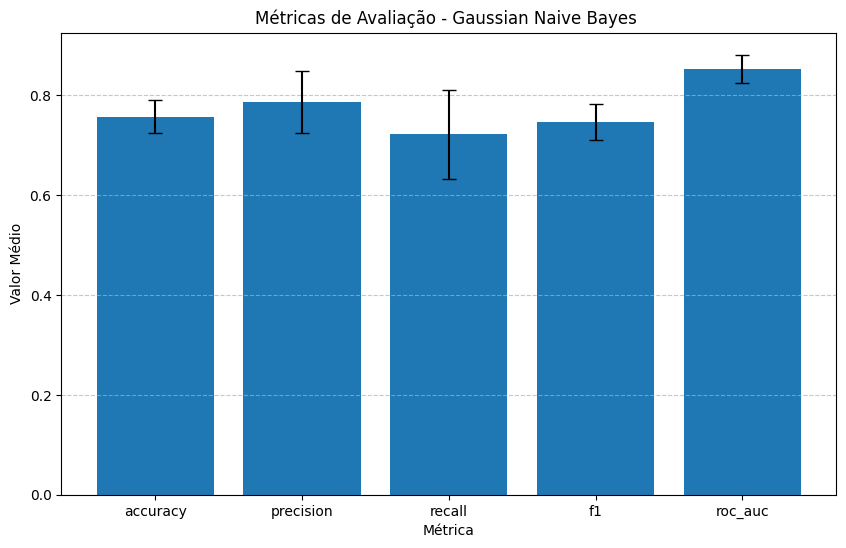

In [26]:
# Importações de bibliotecas necessárias para carregar dados, processamento e visualização
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Importações do scikit-learn para modelagem, validação e pipelines
from sklearn.model_selection import cross_validate, GridSearchCV, StratifiedKFold
from sklearn.naive_bayes import GaussianNB  # Modelo Gaussian Naive Bayes
from sklearn.pipeline import Pipeline                # Para encadear transformações e modelo
from sklearn.preprocessing import StandardScaler     # Para padronizar os dados

# Carregar o conjunto de dados fornecido
# O arquivo 'californiabin.csv' contém 8 features e 1 target binário
df = pd.read_csv('californiabin.csv')

# Separar as variáveis independentes (X) e a variável dependente (y)
# As 8 primeiras colunas são os atributos (features)
# Contamos as colunas de 0 a 8 totalizando 9 colunas
X = df.iloc[:, :8] # o ':8' seleciona todas as colunas de 0 a 7
# A 9ª coluna é a saída binária (0 ou 1)
y = df.iloc[:, 8] # o '8' seleciona somente a ultima coluna que é a 9° coluna

# Pipeline: classe do scit-learn que permite aplicar transformações (padronização) e modelo em sequência
# para evitar vazamento de dados entre treino e teste
pipe = Pipeline([
    ('scaler', StandardScaler()),      # idenficamos a primeira etapa do pipeline (scaler) e padronizamos os dados (média zero e desvio padrão 1) com o objeto StandardScaler
    ('gnb', GaussianNB())   # etapa do pipeline (gnb), usamos o modelo de modelo Gaussian Naive Bayes 'GaussianNB'
])

# o modelo Gaussian Naive Bayes (GaussianNB) não tem muitos hiperparâmetros para ajustar, mas vamos definir um grid vazio
# para manter a mesma estrutura de GridSearchCV
param_grid = {}

# Configurar validação cruzada interna para ajuste de hiperparâmetros
# 5 folds internos
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # 'inner_cv' é a validação usada para escolher os melhores hiperparâmetros, 'StratifiedKFold' usado pelo scikit-learn divide os dados em folds mantendo a proporção de classes, 'n_splits=5' cria 5 grupos para validação cruzada interna, 'shuffle=True' embaralha os dados antes de dividir, 'random_state=42' garante reprodutibilidade.


# GridSearchCV busca os melhores hiperparâmetros dentro de cada fold interno
# Isso evita overfitting nos hiperparâmetros
grid_search = GridSearchCV(pipe, param_grid, cv=inner_cv, scoring='accuracy', n_jobs=-1) #'grid_search' é o objeto usado para validação cruzada externa (10 folds) para o GridSearchCV encontrar os melhores hiperparêmetros, pipe → Pipeline com transformações e modelo, 'param_grid' testa combinações de hiperparâmetros, 'cv=inner_cv' define validação cruzada interna (5 folds), scoring='accuracy' métrica usada para comparar os modelos, n_jobs=-1 usa todos os núcleos do processador para acelerar os cálculos.

# Configurar validação cruzada externa para estimar a performance real do modelo
# 10 folds externos (como pedido no enunciado)
outer_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42) # 'outer_cv' variável que armazena a estratégia de validação cruzada externa, 'StratifiedKFold' divisão dos dados mantendo a proporção de classes, 'n_splits=10' 10 grupos para validação cruzada externa, 'shuffle=True' embaralha os dados antes de dividir e 'random_state=42' garante reprodutibilidade.

# Lista de métricas a serem avaliadas no modelo
# Accuracy: fração de acertos
# Precision: qualidade das previsões positivas
# Recall: cobertura dos positivos reais
# F1: média harmônica entre precision e recall
# Roc-Auc: Classificação Binária
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# Aplicar validação cruzada aninhada com múltiplas métricas
# Retorna um dicionário com os scores para cada métrica
nested_results = cross_validate(grid_search, X, y, cv=outer_cv, scoring=scoring, # 'nested_results' armazena os resultados da validação cruzada, 'cross_validate' função que executa validação cruzada com múltiplas métricas, 'grid_search' objeto que encapsula o modelo e busca de hiperparâmetros, 'X e y' são os dados de entrada, 'cv=outer_cv' definie os 10 folds externos, 'scoring=scoring' define as métricas a serem calculadas
                               return_train_score=False, n_jobs=-1) #'return_train_score=False' não retorna scores de treino, 'n_jobs=-1' usa todos os núcelos do processador para acelerar os cálculos

# Exibir os resultados para cada métrica
print("Resultados de Neives Bayes Gaussiano:\n")

# Iterar sobre cada métrica e imprimir os scores individuais e médios
for metric in scoring: #loope que percore cada métrica definida em scoring (accuracy, precision, recall e f1)
    scores = nested_results[f'test_{metric}']  # extrai/cria os scores de teste para a métrica, 'nasted_results' é um dicionário retornado pelo cross_validate
    print(f"{metric.capitalize()}:")           # imprime o nome da métrica com a primeira letra maiúscula
    print(f"  Scores: {[f'{s:.4f}' for s in scores]}")  # imprime os scores individuais para cada fold pegando cada score do array formatando em 4 casas deciamais
    print(f"  Média: {scores.mean():.4f}")              # imprime a média dos scores formatando em 4 casas decimais
    print(f"  Desvio padrão: {scores.std():.4f}\n")     # imprime o desvio padrão dos scores, formatando em 4 casas decimais e adicionando uma linha para espaçamento

# Visualização gráfica das métricas
# Calcula média e desvio padrão de cada métrica para plotagem
# variável que vai armazenar o dicionário resultante com as médias das métricas de avaliação
metrics_mean = {m: nested_results[f'test_{m}'].mean() for m in scoring} #'metrics_mean' variável que armazena o dicionário final, 'm' variável temporária que assume cada métrica, 'nested_results' dicionário com os scores de cada métrica, 'f'test_{m}'' chave dinâmica para acessar o array de scores, '.mean()' usada pela biblioteca Numpy/Pandas e calcula a média dos scores e 'for m in scoring' loop que percorre todas as métricas
metrics_std = {m: nested_results[f'test_{m}'].std() for m in scoring}  #'metrics_mean' variável que armazena o dicionário final, 'm' variável temporária que assume cada métrica, 'nested_results' dicionário com os scores de cada métrica, 'f'test_{m}'' chave dinâmica para acessar o array de scores, '.std()' usada pela biblioteca Numpy/Pandas e calcula a desvio padrão dos scores e 'for m in scoring' loop que percorre todas as métricas

# Gráfico de barras mostrando as métricas e suas variações
plt.figure(figsize=(10, 6)) #definimos o tameno da figura em 10 polegadas de largura e 6 polegadas de altura
plt.bar(metrics_mean.keys(), metrics_mean.values(), yerr=list(metrics_std.values()), capsize=5) #'plt.bar' cria um gráfico de barras, 'metrics_mean.keys()' chama o nome das métricas, 'metrics_mean.values()' chama os valores médios das métricas (altura das barras), 'yerr=list(metrics_std.values())' barras de desvios padrão, 'capsize=5' tamaho das barbas nas extremidades das barras de erro
plt.title('Métricas de Avaliação - Gaussian Naive Bayes ') #imprime o título do gráfico
plt.ylabel('Valor Médio') # imprime o rótulo do eixo y
plt.xlabel('Métrica') #imprime o rótulo do eixo x
plt.grid(axis='y', linestyle='--', alpha=0.7) #imprime as linhas de grade no eixo y, 'linestyle='--'' traços pontilhados, 'alpha-0,7' trabsparência das linhas
plt.show() #plota o gráfico

**KNN**

Resultados do K-Nearest Neighbors (KNN):

Accuracy:
  Scores: ['0.8750', '0.8450', '0.8550', '0.8750', '0.8150', '0.8500', '0.7900', '0.9200', '0.8050', '0.8392']
  Média: 0.8469
  Desvio padrão: 0.0362

Precision:
  Scores: ['0.8571', '0.8350', '0.8318', '0.8641', '0.7739', '0.8365', '0.7900', '0.9200', '0.8211', '0.8384']
  Média: 0.8368
  Desvio padrão: 0.0381

Recall:
  Scores: ['0.9000', '0.8600', '0.8900', '0.8900', '0.8900', '0.8700', '0.7900', '0.9200', '0.7800', '0.8384']
  Média: 0.8628
  Desvio padrão: 0.0444

F1:
  Scores: ['0.8780', '0.8473', '0.8599', '0.8768', '0.8279', '0.8529', '0.7900', '0.9200', '0.8000', '0.8384']
  Média: 0.8491
  Desvio padrão: 0.0364

Roc_auc:
  Scores: ['0.9489', '0.9395', '0.9225', '0.9441', '0.9253', '0.9270', '0.8952', '0.9602', '0.9127', '0.9029']
  Média: 0.9278
  Desvio padrão: 0.0196



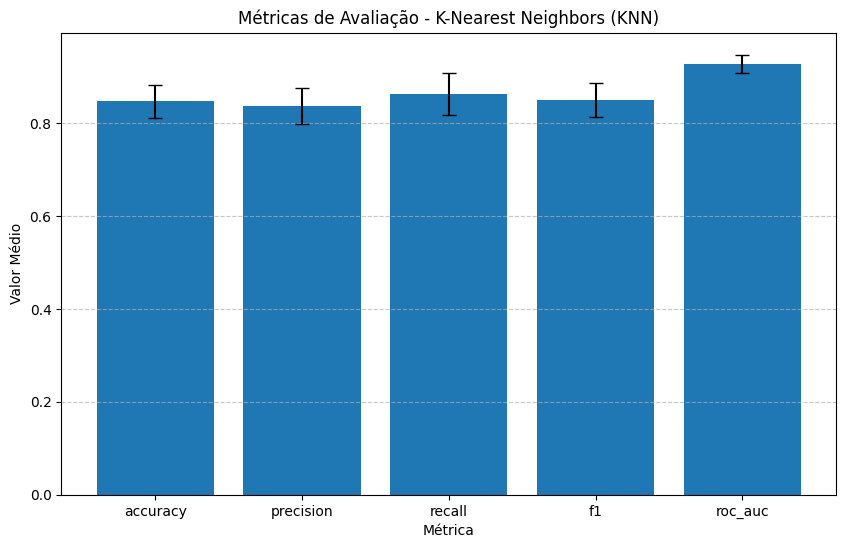

In [27]:
# Importações de bibliotecas necessárias para carregar dados, processamento e visualização
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Importações do scikit-learn para modelagem, validação e pipelines
from sklearn.model_selection import cross_validate, GridSearchCV, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier  # Modelo KNN
from sklearn.pipeline import Pipeline                # Para encadear transformações e modelo
from sklearn.preprocessing import StandardScaler     # Para padronizar os dados

# Carregar o conjunto de dados fornecido
# O arquivo 'californiabin.csv' contém 8 features e 1 target binário
df = pd.read_csv('californiabin.csv')

# Separar as variáveis independentes (X) e a variável dependente (y)
# As 8 primeiras colunas são os atributos (features)
# Contamos as colunas de 0 a 8 totalizando 9 colunas
X = df.iloc[:, :8] # o ':8' seleciona todas as colunas de 0 a 7
# A 9ª coluna é a saída binária (0 ou 1)
y = df.iloc[:, 8] # o '8' seleciona somente a ultima coluna que é a 9° coluna

# Pipeline: classe do scit-learn que permite aplicar transformações (padronização) e modelo em sequência
# para evitar vazamento de dados entre treino e teste
pipe = Pipeline([
    ('scaler', StandardScaler()),      # idenficamos a primeira etapa do pipeline (scaler) e padronizamos os dados (média zero e desvio padrão 1) com o objeto StandardScaler
    ('knn', KNeighborsClassifier())   # idenfificamos a segunda etapa do pipeline (knn), usamos o modelo de KNN 'KNeighborsClassifier'
])

# LDA não tem muitos hiperparâmetros para ajustar, mas vamos definir um grid vazio
# para manter a mesma estrutura de GridSearchCV
param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9, 11],    # Número de vizinhos
    'knn__weights': ['uniform', 'distance'],  # Uniforme ou ponderado por distância
    'knn__metric': ['euclidean', 'manhattan'] # Distância usada
}

# Configurar validação cruzada interna para ajuste de hiperparâmetros
# 5 folds internos
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # 'inner_cv' é a validação usada para escolher os melhores hiperparâmetros, 'StratifiedKFold' usado pelo scikit-learn divide os dados em folds mantendo a proporção de classes, 'n_splits=5' cria 5 grupos para validação cruzada interna, 'shuffle=True' embaralha os dados antes de dividir, 'random_state=42' garante reprodutibilidade.


# GridSearchCV busca os melhores hiperparâmetros dentro de cada fold interno
# Isso evita overfitting nos hiperparâmetros
grid_search = GridSearchCV(pipe, param_grid, cv=inner_cv, scoring='accuracy', n_jobs=-1) #'grid_search' é o objeto usado para validação cruzada externa (10 folds) para o GridSearchCV encontrar os melhores hiperparêmetros, pipe → Pipeline com transformações e modelo, 'param_grid' testa combinações de hiperparâmetros, 'cv=inner_cv' define validação cruzada interna (5 folds), scoring='accuracy' métrica usada para comparar os modelos, n_jobs=-1 usa todos os núcleos do processador para acelerar os cálculos.

# Configurar validação cruzada externa para estimar a performance real do modelo
# 10 folds externos (como pedido no enunciado)
outer_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42) # 'outer_cv' variável que armazena a estratégia de validação cruzada externa, 'StratifiedKFold' divisão dos dados mantendo a proporção de classes, 'n_splits=10' 10 grupos para validação cruzada externa, 'shuffle=True' embaralha os dados antes de dividir e 'random_state=42' garante reprodutibilidade.

# Lista de métricas a serem avaliadas no modelo
# Accuracy: fração de acertos
# Precision: qualidade das previsões positivas
# Recall: cobertura dos positivos reais
# F1: média harmônica entre precision e recall
# Roc-Auc: Classificação Binária
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# Aplicar validação cruzada aninhada com múltiplas métricas
# Retorna um dicionário com os scores para cada métrica
nested_results = cross_validate(grid_search, X, y, cv=outer_cv, scoring=scoring, # 'nested_results' armazena os resultados da validação cruzada, 'cross_validate' função que executa validação cruzada com múltiplas métricas, 'grid_search' objeto que encapsula o modelo e busca de hiperparâmetros, 'X e y' são os dados de entrada, 'cv=outer_cv' definie os 10 folds externos, 'scoring=scoring' define as métricas a serem calculadas
                               return_train_score=False, n_jobs=-1) #'return_train_score=False' não retorna scores de treino, 'n_jobs=-1' usa todos os núcelos do processador para acelerar os cálculos

# Exibir os resultados para cada métrica
print("Resultados do K-Nearest Neighbors (KNN):\n")

# Iterar sobre cada métrica e imprimir os scores individuais e médios
for metric in scoring: #loope que percore cada métrica definida em scoring (accuracy, precision, recall e f1)
    scores = nested_results[f'test_{metric}']  # extrai/cria os scores de teste para a métrica, 'nasted_results' é um dicionário retornado pelo cross_validate
    print(f"{metric.capitalize()}:")           # imprime o nome da métrica com a primeira letra maiúscula
    print(f"  Scores: {[f'{s:.4f}' for s in scores]}")  # imprime os scores individuais para cada fold pegando cada score do array formatando em 4 casas deciamais
    print(f"  Média: {scores.mean():.4f}")              # imprime a média dos scores formatando em 4 casas decimais
    print(f"  Desvio padrão: {scores.std():.4f}\n")     # imprime o desvio padrão dos scores, formatando em 4 casas decimais e adicionando uma linha para espaçamento

# Visualização gráfica das métricas
# Calcula média e desvio padrão de cada métrica para plotagem
# variável que vai armazenar o dicionário resultante com as médias das métricas de avaliação
metrics_mean = {m: nested_results[f'test_{m}'].mean() for m in scoring} #'metrics_mean' variável que armazena o dicionário final, 'm' variável temporária que assume cada métrica, 'nested_results' dicionário com os scores de cada métrica, 'f'test_{m}'' chave dinâmica para acessar o array de scores, '.mean()' usada pela biblioteca Numpy/Pandas e calcula a média dos scores e 'for m in scoring' loop que percorre todas as métricas
metrics_std = {m: nested_results[f'test_{m}'].std() for m in scoring}  #'metrics_mean' variável que armazena o dicionário final, 'm' variável temporária que assume cada métrica, 'nested_results' dicionário com os scores de cada métrica, 'f'test_{m}'' chave dinâmica para acessar o array de scores, '.std()' usada pela biblioteca Numpy/Pandas e calcula a desvio padrão dos scores e 'for m in scoring' loop que percorre todas as métricas

# Gráfico de barras mostrando as métricas e suas variações
plt.figure(figsize=(10, 6)) #definimos o tameno da figura em 10 polegadas de largura e 6 polegadas de altura
plt.bar(metrics_mean.keys(), metrics_mean.values(), yerr=list(metrics_std.values()), capsize=5) #'plt.bar' cria um gráfico de barras, 'metrics_mean.keys()' chama o nome das métricas, 'metrics_mean.values()' chama os valores médios das métricas (altura das barras), 'yerr=list(metrics_std.values())' barras de desvios padrão, 'capsize=5' tamaho das barbas nas extremidades das barras de erro
plt.title('Métricas de Avaliação - K-Nearest Neighbors (KNN)') #imprime o título do gráfico
plt.ylabel('Valor Médio') # imprime o rótulo do eixo y
plt.xlabel('Métrica') #imprime o rótulo do eixo x
plt.grid(axis='y', linestyle='--', alpha=0.7) #imprime as linhas de grade no eixo y, 'linestyle='--'' traços pontilhados, 'alpha-0,7' trabsparência das linhas
plt.show() #plota o gráfico

**Árvore de Decisão**

Resultados da Árvore de Decisão

Accuracy:
  Scores: ['0.8150', '0.8650', '0.8350', '0.8500', '0.7600', '0.8350', '0.8000', '0.8600', '0.7900', '0.8191']
  Média: 0.8229
  Desvio padrão: 0.0313

Precision:
  Scores: ['0.8387', '0.8687', '0.8454', '0.8646', '0.7453', '0.8317', '0.8125', '0.8750', '0.8295', '0.8182']
  Média: 0.8330
  Desvio padrão: 0.0355

Recall:
  Scores: ['0.7800', '0.8600', '0.8200', '0.8300', '0.7900', '0.8400', '0.7800', '0.8400', '0.7300', '0.8182']
  Média: 0.8088
  Desvio padrão: 0.0367

F1:
  Scores: ['0.8083', '0.8643', '0.8325', '0.8469', '0.7670', '0.8358', '0.7959', '0.8571', '0.7766', '0.8182']
  Média: 0.8203
  Desvio padrão: 0.0314

Roc_auc:
  Scores: ['0.8762', '0.8650', '0.8350', '0.8787', '0.8372', '0.8518', '0.8615', '0.8902', '0.8586', '0.8922']
  Média: 0.8646
  Desvio padrão: 0.0189



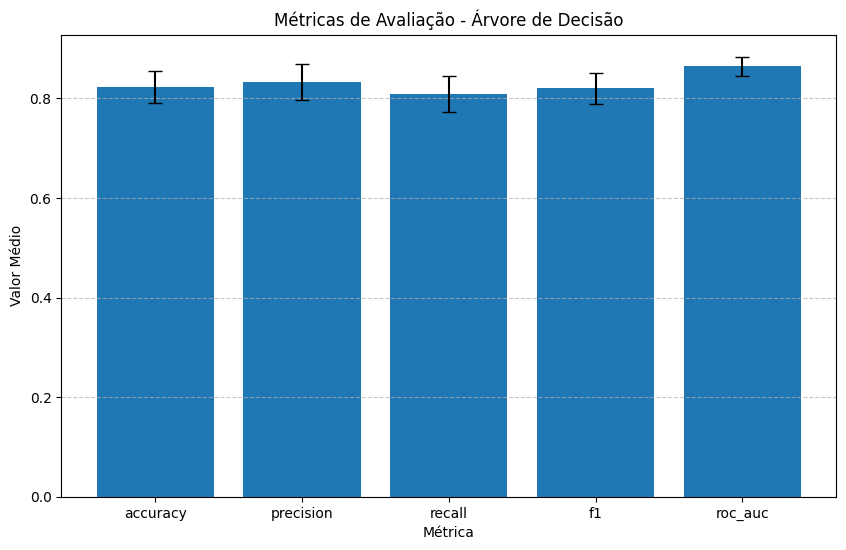

In [28]:
# Importações de bibliotecas necessárias para carregar dados, processamento e visualização
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Importações do scikit-learn para modelagem, validação e pipelines
from sklearn.model_selection import cross_validate, GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier  # Modelo Árvore de Decisão
from sklearn.pipeline import Pipeline                # Para encadear transformações e modelo
from sklearn.preprocessing import StandardScaler     # Para padronizar os dados

# Carregar o conjunto de dados fornecido
# O arquivo 'californiabin.csv' contém 8 features e 1 target binário
df = pd.read_csv('californiabin.csv')

# Separar as variáveis independentes (X) e a variável dependente (y)
# As 8 primeiras colunas são os atributos (features)
# Contamos as colunas de 0 a 8 totalizando 9 colunas
X = df.iloc[:, :8] # o ':8' seleciona todas as colunas de 0 a 7
# A 9ª coluna é a saída binária (0 ou 1)
y = df.iloc[:, 8] # o '8' seleciona somente a ultima coluna que é a 9° coluna

# Pipeline: classe do scit-learn que permite aplicar transformações (padronização) e modelo em sequência
# para evitar vazamento de dados entre treino e teste
pipe = Pipeline([
    ('scaler', StandardScaler()),      # idenficamos a primeira etapa do pipeline (scaler) e padronizamos os dados (média zero e desvio padrão 1) com o objeto StandardScaler
    ('tree', DecisionTreeClassifier(random_state=42))   # segunda etapa do pipeline (tree), usamos o modelo de Árvore de Decisão 'DecisionTreeClassifier' e 'random_state=42' garante reprodutibilidade.
])

# LDA não tem muitos hiperparâmetros para ajustar, mas vamos definir um grid vazio
# para manter a mesma estrutura de GridSearchCV
param_grid = {
    'tree__max_depth': [3, 5, 7, 10, None],         # Profundidade máxima da árvore
    'tree__min_samples_split': [2, 5, 10],          # Mínimo de amostras para dividir
    'tree__min_samples_leaf': [1, 2, 4],            # Mínimo de amostras em folhas
    'tree__criterion': ['gini', 'entropy']          # Critério de divisão
}


# Configurar validação cruzada interna para ajuste de hiperparâmetros
# 5 folds internos
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # 'inner_cv' é a validação usada para escolher os melhores hiperparâmetros, 'StratifiedKFold' usado pelo scikit-learn divide os dados em folds mantendo a proporção de classes, 'n_splits=5' cria 5 grupos para validação cruzada interna, 'shuffle=True' embaralha os dados antes de dividir, 'random_state=42' garante reprodutibilidade.


# GridSearchCV busca os melhores hiperparâmetros dentro de cada fold interno
# Isso evita overfitting nos hiperparâmetros
grid_search = GridSearchCV(pipe, param_grid, cv=inner_cv, scoring='accuracy', n_jobs=-1) #'grid_search' é o objeto usado para validação cruzada externa (10 folds) para o GridSearchCV encontrar os melhores hiperparêmetros, pipe → Pipeline com transformações e modelo, 'param_grid' testa combinações de hiperparâmetros, 'cv=inner_cv' define validação cruzada interna (5 folds), scoring='accuracy' métrica usada para comparar os modelos, n_jobs=-1 usa todos os núcleos do processador para acelerar os cálculos.

# Configurar validação cruzada externa para estimar a performance real do modelo
# 10 folds externos (como pedido no enunciado)
outer_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42) # 'outer_cv' variável que armazena a estratégia de validação cruzada externa, 'StratifiedKFold' divisão dos dados mantendo a proporção de classes, 'n_splits=10' 10 grupos para validação cruzada externa, 'shuffle=True' embaralha os dados antes de dividir e 'random_state=42' garante reprodutibilidade.

# Lista de métricas a serem avaliadas no modelo
# Accuracy: fração de acertos
# Precision: qualidade das previsões positivas
# Recall: cobertura dos positivos reais
# F1: média harmônica entre precision e recall
# Roc-Auc: Classificação Binária
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# Aplicar validação cruzada aninhada com múltiplas métricas
# Retorna um dicionário com os scores para cada métrica
nested_results = cross_validate(grid_search, X, y, cv=outer_cv, scoring=scoring, # 'nested_results' armazena os resultados da validação cruzada, 'cross_validate' função que executa validação cruzada com múltiplas métricas, 'grid_search' objeto que encapsula o modelo e busca de hiperparâmetros, 'X e y' são os dados de entrada, 'cv=outer_cv' definie os 10 folds externos, 'scoring=scoring' define as métricas a serem calculadas
                               return_train_score=False, n_jobs=-1) #'return_train_score=False' não retorna scores de treino, 'n_jobs=-1' usa todos os núcelos do processador para acelerar os cálculos

# Exibir os resultados para cada métrica
print("Resultados da Árvore de Decisão\n")

# Iterar sobre cada métrica e imprimir os scores individuais e médios
for metric in scoring: #loope que percore cada métrica definida em scoring (accuracy, precision, recall e f1)
    scores = nested_results[f'test_{metric}']  # extrai/cria os scores de teste para a métrica, 'nasted_results' é um dicionário retornado pelo cross_validate
    print(f"{metric.capitalize()}:")           # imprime o nome da métrica com a primeira letra maiúscula
    print(f"  Scores: {[f'{s:.4f}' for s in scores]}")  # imprime os scores individuais para cada fold pegando cada score do array formatando em 4 casas deciamais
    print(f"  Média: {scores.mean():.4f}")              # imprime a média dos scores formatando em 4 casas decimais
    print(f"  Desvio padrão: {scores.std():.4f}\n")     # imprime o desvio padrão dos scores, formatando em 4 casas decimais e adicionando uma linha para espaçamento

# Visualização gráfica das métricas
# Calcula média e desvio padrão de cada métrica para plotagem
# variável que vai armazenar o dicionário resultante com as médias das métricas de avaliação
metrics_mean = {m: nested_results[f'test_{m}'].mean() for m in scoring} #'metrics_mean' variável que armazena o dicionário final, 'm' variável temporária que assume cada métrica, 'nested_results' dicionário com os scores de cada métrica, 'f'test_{m}'' chave dinâmica para acessar o array de scores, '.mean()' usada pela biblioteca Numpy/Pandas e calcula a média dos scores e 'for m in scoring' loop que percorre todas as métricas
metrics_std = {m: nested_results[f'test_{m}'].std() for m in scoring}  #'metrics_mean' variável que armazena o dicionário final, 'm' variável temporária que assume cada métrica, 'nested_results' dicionário com os scores de cada métrica, 'f'test_{m}'' chave dinâmica para acessar o array de scores, '.std()' usada pela biblioteca Numpy/Pandas e calcula a desvio padrão dos scores e 'for m in scoring' loop que percorre todas as métricas

# Gráfico de barras mostrando as métricas e suas variações
plt.figure(figsize=(10, 6)) #definimos o tameno da figura em 10 polegadas de largura e 6 polegadas de altura
plt.bar(metrics_mean.keys(), metrics_mean.values(), yerr=list(metrics_std.values()), capsize=5) #'plt.bar' cria um gráfico de barras, 'metrics_mean.keys()' chama o nome das métricas, 'metrics_mean.values()' chama os valores médios das métricas (altura das barras), 'yerr=list(metrics_std.values())' barras de desvios padrão, 'capsize=5' tamaho das barbas nas extremidades das barras de erro
plt.title('Métricas de Avaliação - Árvore de Decisão') #imprime o título do gráfico
plt.ylabel('Valor Médio') # imprime o rótulo do eixo y
plt.xlabel('Métrica') #imprime o rótulo do eixo x
plt.grid(axis='y', linestyle='--', alpha=0.7) #imprime as linhas de grade no eixo y, 'linestyle='--'' traços pontilhados, 'alpha-0,7' trabsparência das linhas
plt.show() #plota o gráfico